## Ejercicio 6

Se requiere evaluar la performance en la recuperación de un sistema. Para una consulta q1, dicho sistema entregó la siguiente salida:

1	2 3	4	5	6	7	8	9	10 11 12 13	14 15

R	N	N	R	R	N	N	N	N	R  N	N	 N	R	 N
	 	 	 	 	 	
Los documentos identificados como R son los relevantes, mientras que las N’s corresponden a documentos no relevantes a q1. Suponga, además, que existen en el corpus otros 6 documentos relevantes a q1 que el sistema no recuperó. A partir de esta salida, calcule las siguientes medidas:

a)	Recall y Precisión para cada posición j.
b)	Precisión promedio. 
c)	Precisión al 50 % de Recall.
d)	Precisión-R.
e)	DCG@10, IDCG@10 y nDCG@10 
f)	MRR

Finalmente, realice las gráficas interpolada y sin interpolar. Luego, interprete brevemente los resultados y brinde una explicación.


In [1]:
import matplotlib.pyplot as plt

# Datos del problema (1 = relevante, 0 = no relevante)
relevancia = [1,0,0,1,1,0,0,0,0,1,0,0,0,1,0]

total_relevantes = 11

precision = []
recall = []

relevantes_acum = 0

In [2]:
# Calcular precision y recall en cada posición
for i, rel in enumerate(relevancia, start=1):
    if rel == 1:
        relevantes_acum += 1
    
    p = relevantes_acum / i
    r = relevantes_acum / total_relevantes
    
    precision.append(p)
    recall.append(r)

## Curva SIN interpolar

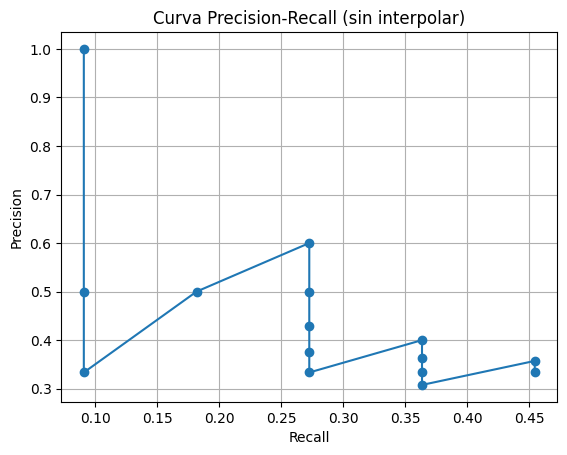

In [3]:
plt.figure()
plt.plot(recall, precision, marker='o')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall (sin interpolar)")
plt.grid()

## Curva Interpolada

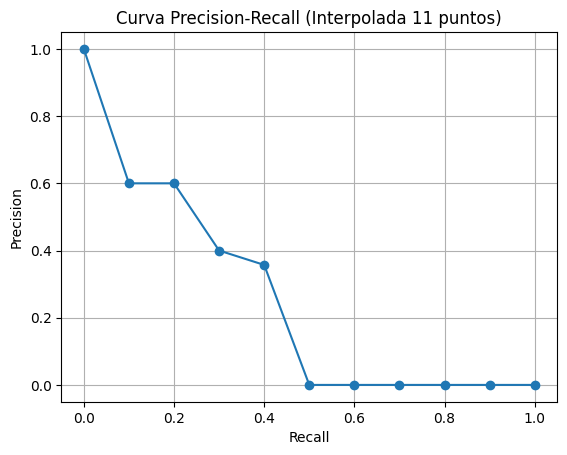

In [4]:
niveles_recall = [i/10 for i in range(11)]
precision_interp = []

for nivel in niveles_recall:
    precisiones_validas = [p for p, r in zip(precision, recall) if r >= nivel]
    
    if precisiones_validas:
        precision_interp.append(max(precisiones_validas))
    else:
        precision_interp.append(0)

plt.figure()
plt.plot(niveles_recall, precision_interp, marker='o')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall (Interpolada 11 puntos)")
plt.grid()

plt.show()